# Cyclistic Case Study – Analyze

This notebook explores differences in **bike usage patterns between annual members and casual riders** using the cleaned dataset.

## Analysis Objective

The objective of this analysis is to identify behavioral differences between annual members and casual riders.  
These insights will help Cyclistic design targeted marketing strategies aimed at converting casual riders into annual members.

## Scope of Analysis

The analysis focuses on:
- Trip duration
- Ride frequency
- Time of day usage
- Weekday vs weekend behavior
- Seasonal patterns

All analysis is performed using SQL queries on the processed dataset.


## DataBase connection


In [2]:
from sqlalchemy import create_engine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

server = "Knok\\SQLEXPRESS"
database = "Analysis"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

## Analysis 01: Weekday vs Weekend Usage by Rider Type

How does ride frequency differ between annual members and casual riders during weekdays and weekends?

In [ ]:

query_weekend = """
SELECT
    member_casual,
    is_weekend,
    COUNT(*) AS total_rides
FROM dbo.cyclistic
GROUP BY
    member_casual,
    is_weekend
ORDER BY
    member_casual,
    is_weekend;
"""

df_weekend = pd.read_sql(query_weekend, con=engine)
df_weekend

,member_casual,is_weekend,total_rides
0,casual,False,7723328
1,casual,True,4809341
2,member,False,14759201
3,member,True,4873793


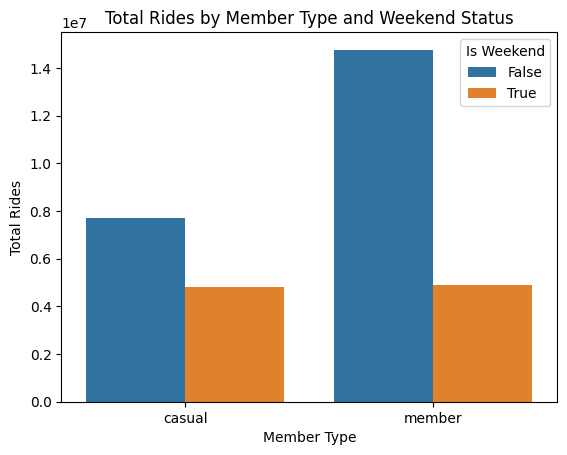

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df_weekend, x="member_casual", y="total_rides", hue="is_weekend")
plt.title("Total Rides by Member Type and Weekend Status")
plt.xlabel("Member Type")
plt.ylabel("Total Rides")
plt.legend(title="Is Weekend")


### Insight

Annual members account for substantially more rides during weekdays than casual riders.  
This pattern suggests that members primarily use Cyclistic bikes for routine, utilitarian purposes such as commuting.

On weekends, ride volumes for members and casual riders are nearly identical.  
This indicates that leisure‑oriented bike usage is common across both groups, regardless of membership status.

### Business Relevance

The largest behavioral difference between the two rider groups occurs during weekdays.  
This suggests that marketing efforts promoting annual memberships should emphasize weekday commuting benefits rather than weekend leisure use.

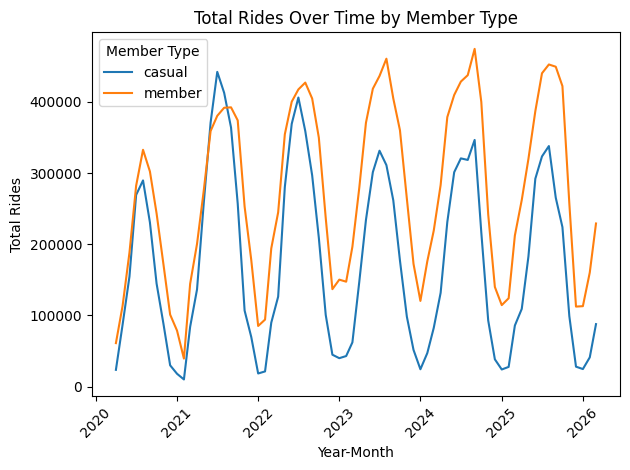

In [3]:
query_time_series = """
SELECT
    DATEADD(MONTH, DATEDIFF(MONTH, 0, started_at), 0) AS year_month,
    member_casual,
    COUNT(*) AS total_rides
FROM dbo.cyclistic
GROUP BY
    DATEADD(MONTH, DATEDIFF(MONTH, 0, started_at), 0),
    member_casual
ORDER BY
    year_month,
    member_casual;
"""
df_time_series = pd.read_sql(query_time_series, con=engine)
df_time_series
sns.lineplot(data=df_time_series, x="year_month", y="total_rides", hue="member_casual")
plt.title("Total Rides Over Time by Member Type")
plt.xlabel("Year-Month")
plt.ylabel("Total Rides")
plt.legend(title="Member Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly ride volumes reveal strong seasonality across both rider groups, with usage
peaking during summer months. While both casual and annual riders follow similar
seasonal patterns, annual members consistently generate a higher number of rides
throughout the year. This suggests more frequent and routine usage among members,
independent of seasonal effects.

we are still not sure if member increase is caused by bigger usage per customer or overall membership inncrease
- analysis needed :  duration, memmbership increase, the most frequent times
